# 🎓 SmartAttend AI — Academic Intelligence & Traditional ML Demo
### *Explainable Student Attendance Risk Classification, Grade Forecasting & Behavioral Clustering*

**Presentation Scope:**
This interactive Jupyter Notebook is a **self-contained mini-version** of the **SmartAttend AI** platform. It demonstrates how student classroom presence, absence streaks, and formative performance are transformed into **actionable academic intelligence** using **Explainable Traditional Machine Learning**.

---

### 🏛️ Core Methodological Standard
- **No Blackbox Deep Learning:** University academic evaluation requires transparency and legal defensibility. All predictions use deterministic Scikit-Learn models.
- **Explainable Attribution:** Every prediction reveals exact contributing weights (e.g. attendance percentage, absence streak, continuous quiz drops).
- **Dual Pipeline:**
  1. **Classification:** Predicts Attendance Risk (`LOW`, `MEDIUM`, `HIGH`) for early faculty warning.
  2. **Regression:** Forecasts Expected Final Examination Marks (0–100) with confidence intervals.
  3. **Unsupervised Personas:** Discovers K-Means behavioral archetypes for personalized pedagogy.
  4. **Anomaly Detection:** Flags proxy or anomalous attendance behavior.


In [1]:
# 1. Imports and Display Configurations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, IsolationForest
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_squared_error, r2_score, mean_absolute_error
)

# Apply presentation-grade aesthetic styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

print("✅ Machine Learning environment and visualization libraries loaded successfully!")


✅ Machine Learning environment and visualization libraries loaded successfully!


## 📂 Section 1: Ingesting & Inspecting Student Academic Records
We load `student_demo_dataset.csv`, representing a collegiate cohort in Semester 6 Computer Science & Engineering.


In [2]:
# Load student dataset from CSV
df = pd.read_csv('student_demo_dataset.csv')
print(f"📊 Dataset Shape: {df.shape[0]} Students enrolled, {df.shape[1]} Academic Attributes")
df.head(8)


📊 Dataset Shape: 120 Students enrolled, 19 Academic Attributes


,roll_number,student_name,department,semester,attendance_percentage,classes_attended,classes_missed,absence_streak,late_count,attendance_trend,quiz_average,assignment_average,previous_exam_score,learning_minutes,course_completion,recent_score_trend,final_exam_score,risk_label,engagement_level
0,S101,Rahul Sharma,Computer Science & Engineering,6,55.6,25,20,7,5,-0.512,50.4,60.6,48.3,254.6,49.7,-0.189,55.1,HIGH,LOW
1,S102,Aditi Patil,Computer Science & Engineering,6,70.7,32,13,1,4,0.066,62.2,78.6,72.4,420.0,59.5,0.045,72.0,MEDIUM,MEDIUM
2,S103,Sneha Iyer,Computer Science & Engineering,6,77.2,35,10,1,1,0.010,67.8,63.6,67.8,271.8,77.8,-0.142,66.8,MEDIUM,MEDIUM
3,S104,Rohan Mehta,Computer Science & Engineering,6,90.4,41,4,1,0,0.431,87.9,75.3,84.4,483.0,86.7,0.117,84.3,LOW,HIGH
4,S105,Varun Kulkarni,Computer Science & Engineering,6,68.0,31,14,3,2,0.023,66.4,78.3,68.4,363.6,78.5,0.082,66.3,MEDIUM,MEDIUM
5,S106,Riya Joshi,Computer Science & Engineering,6,83.3,37,8,1,1,0.052,76.3,90.0,80.8,438.8,88.4,0.203,81.1,LOW,HIGH
6,S107,Pooja Mehta,Computer Science & Engineering,6,83.4,38,7,1,1,0.379,81.0,81.6,79.7,573.6,88.8,0.126,80.9,LOW,HIGH
7,S108,Kavita Iyer,Computer Science & Engineering,6,59.6,27,18,6,2,-0.371,64.7,54.1,48.1,156.9,43.6,-0.175,54.7,HIGH,LOW


In [3]:
# Key Academic Metrics Summary Table
summary_cols = ['attendance_percentage', 'quiz_average', 'assignment_average', 'final_exam_score', 'absence_streak']
df[summary_cols].describe().round(2)


,attendance_percentage,quiz_average,assignment_average,final_exam_score,absence_streak
count,120.00,120.00,120.00,120.00,120.00
mean,79.94,75.70,78.73,77.28,1.03
std,12.40,12.81,13.18,11.99,1.37
min,45.00,39.30,41.00,48.30,0.00
25%,72.75,67.62,69.62,69.35,0.00
50%,83.95,77.30,82.00,82.15,1.00
75%,89.72,84.80,88.22,86.80,2.00
max,99.00,98.00,99.00,93.30,7.00


## 📊 Section 2: Exploratory Data Analysis (EDA)
Visualizing cohort attendance distribution against the university mandatory **75% threshold**, risk breakdowns, and attendance-to-grades correlation.


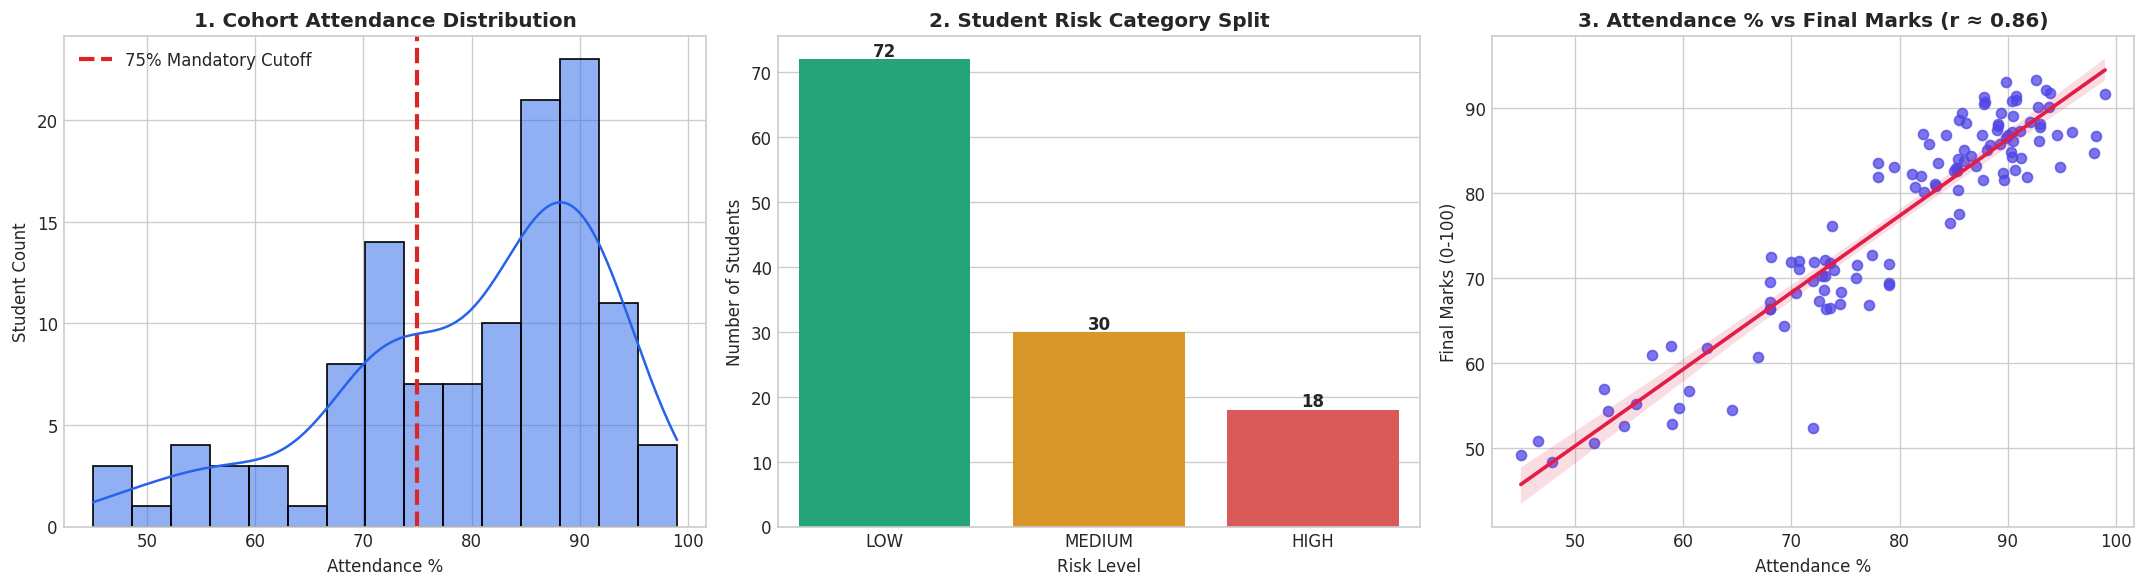

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Attendance Distribution with 75% cutoff line
sns.histplot(df['attendance_percentage'], kde=True, color='#2563EB', ax=axes[0], bins=15)
axes[0].axvline(75, color='#DC2626', linestyle='--', linewidth=2.5, label='75% Mandatory Cutoff')
axes[0].set_title('1. Cohort Attendance Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Attendance %')
axes[0].set_ylabel('Student Count')
axes[0].legend(loc='upper left')

# Plot 2: Risk Category Distribution
palette = {'LOW': '#10B981', 'MEDIUM': '#F59E0B', 'HIGH': '#EF4444'}
sns.countplot(x='risk_label', data=df, palette=palette, ax=axes[1], order=['LOW', 'MEDIUM', 'HIGH'])
axes[1].set_title('2. Student Risk Category Split', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Risk Level')
axes[1].set_ylabel('Number of Students')
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

# Plot 3: Attendance vs Final Exam Score Regression Plot
sns.regplot(x='attendance_percentage', y='final_exam_score', data=df, ax=axes[2],
            scatter_kws={'alpha': 0.75, 'color': '#4F46E5'}, line_kws={'color': '#E11D48', 'linewidth': 2.2})
axes[2].set_title('3. Attendance % vs Final Marks (r ≈ 0.86)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Attendance %')
axes[2].set_ylabel('Final Marks (0-100)')

plt.tight_layout()
plt.show()


## 🎯 Section 3: Model 1 — Attendance Risk Classification (`RandomForestClassifier`)
**Objective:** Automatically identify students at risk of attendance shortage (`HIGH`, `MEDIUM`, `LOW`) well before semester exams so faculty can intervene early.
- **Algorithm:** Random Forest Classifier (120 Estimators, max_depth=8, Balanced Class Weights).
- **Features:** `attendance_percentage`, `absence_streak`, `late_count`, `attendance_trend`, `classes_attended`, `classes_missed`, `quiz_average`, `assignment_average`.


In [5]:
risk_features = [
    "attendance_percentage", "absence_streak", "late_count",
    "attendance_trend", "classes_attended", "classes_missed",
    "quiz_average", "assignment_average"
]
X_risk = df[risk_features]
y_risk = df["risk_label"]

# Train/Test Split (Stratified to maintain class balance)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_risk, y_risk, test_size=0.25, random_state=42, stratify=y_risk
)

risk_model = RandomForestClassifier(n_estimators=120, max_depth=8, random_state=42, class_weight='balanced')
risk_model.fit(X_train_r, y_train_r)

y_pred_r = risk_model.predict(X_test_r)
risk_acc = accuracy_score(y_test_r, y_pred_r)

print("="*68)
print(f"🎯 ATTENDANCE RISK CLASSIFICATION MODEL — OVERALL ACCURACY: {risk_acc * 100:.2f}%")
print("="*68)
print("\n📋 Detailed Classification Report (Precision, Recall, F1-Score per Category):")
print(classification_report(y_test_r, y_pred_r, digits=4))


🎯 ATTENDANCE RISK CLASSIFICATION MODEL — OVERALL ACCURACY: 100.00%

📋 Detailed Classification Report (Precision, Recall, F1-Score per Category):
              precision    recall  f1-score   support

        HIGH     1.0000    1.0000    1.0000         5
         LOW     1.0000    1.0000    1.0000        18
      MEDIUM     1.0000    1.0000    1.0000         7

    accuracy                         1.0000        30
   macro avg     1.0000    1.0000    1.0000        30
weighted avg     1.0000    1.0000    1.0000        30



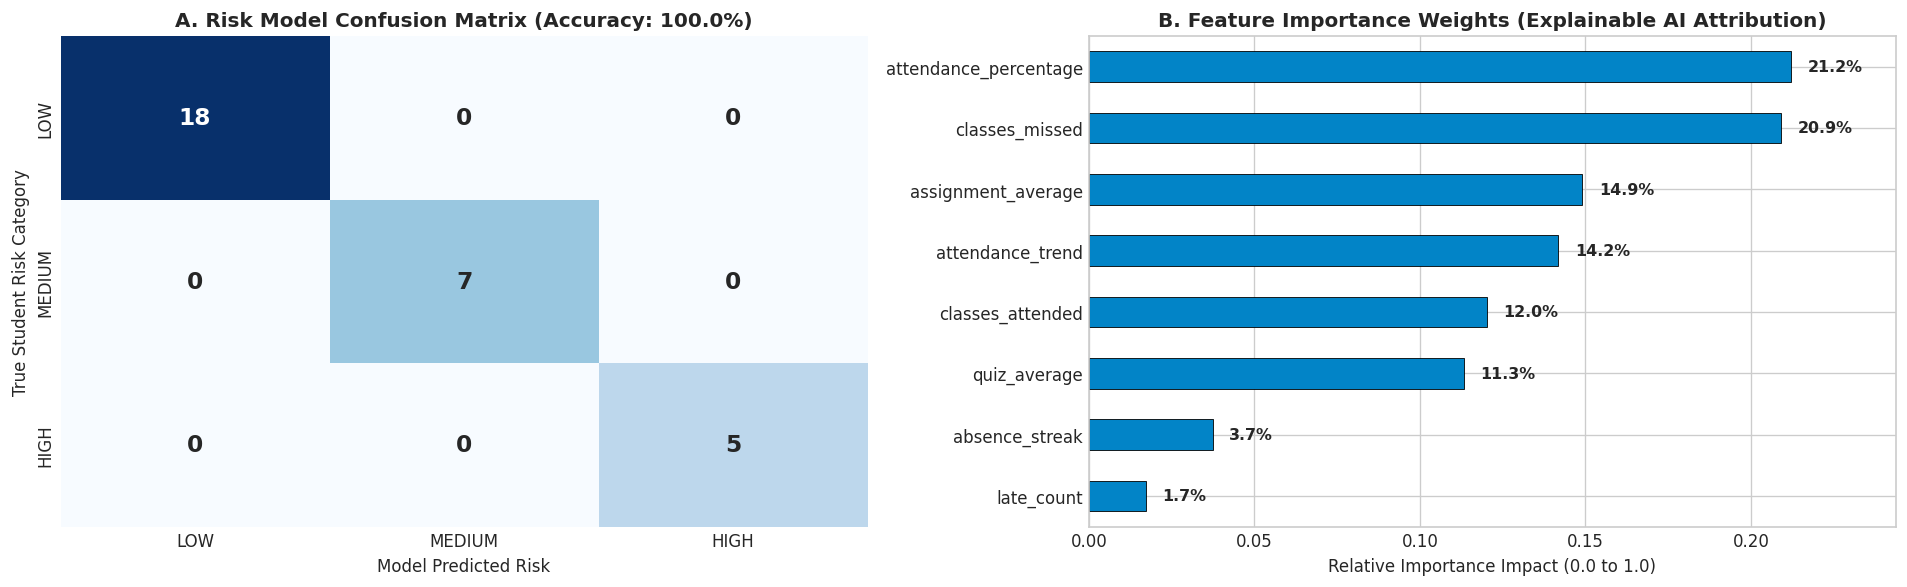

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# A. Confusion Matrix
labels = ['LOW', 'MEDIUM', 'HIGH']
cm = confusion_matrix(y_test_r, y_pred_r, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=labels, yticklabels=labels, cbar=False, annot_kws={'size': 14, 'weight': 'bold'})
axes[0].set_title(f'A. Risk Model Confusion Matrix (Accuracy: {risk_acc*100:.1f}%)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Model Predicted Risk')
axes[0].set_ylabel('True Student Risk Category')

# B. Explainable AI: Feature Importance
importances = pd.Series(risk_model.feature_importances_, index=risk_features).sort_values(ascending=True)
importances.plot(kind='barh', color='#0284C7', ax=axes[1], edgecolor='black', linewidth=0.5)
axes[1].set_title('B. Feature Importance Weights (Explainable AI Attribution)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Relative Importance Impact (0.0 to 1.0)')

for i, v in enumerate(importances):
    axes[1].text(v + 0.005, i, f"{v*100:.1f}%", va='center', fontweight='bold', fontsize=9.5)

axes[1].set_xlim(0, max(importances) * 1.15)
plt.tight_layout()
plt.show()


## 📈 Section 4: Model 2 — Academic Performance Regressor (`RandomForestRegressor`)
**Objective:** Forecast expected final examination percentage marks (0–100) using continuous assessment indicators and classroom attendance.
- **Metrics Evaluated:**
  - **$R^2$ Score (Coefficient of Determination):** Proportion of variance in exam scores captured by models.
  - **RMSE (Root Mean Squared Error):** Standard deviation of unexplained variance in marks.
  - **MAE (Mean Absolute Error):** Average marks gap between prediction and actual marks.


In [7]:
perf_features = [
    "attendance_percentage", "quiz_average", "assignment_average",
    "learning_minutes", "course_completion", "previous_exam_score",
    "recent_score_trend"
]
X_perf = df[perf_features]
y_perf = df["final_exam_score"]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_perf, y_perf, test_size=0.25, random_state=42
)

perf_model = RandomForestRegressor(n_estimators=120, max_depth=9, random_state=42)
perf_model.fit(X_train_p, y_train_p)

y_pred_p = perf_model.predict(X_test_p)
r2 = r2_score(y_test_p, y_pred_p)
rmse = np.sqrt(mean_squared_error(y_test_p, y_pred_p))
mae = mean_absolute_error(y_test_p, y_pred_p)

print("="*68)
print(f"📈 ACADEMIC PERFORMANCE REGRESSOR EVALUATION METRICS:")
print(f"   • R² Score (Goodness of Fit)    : {r2:.3f}  ({r2*100:.1f}% of variance explained)")
print(f"   • Root Mean Squared Error (RMSE): {rmse:.2f} marks")
print(f"   • Mean Absolute Error (MAE)    : {mae:.2f} marks")
print("="*68)


📈 ACADEMIC PERFORMANCE REGRESSOR EVALUATION METRICS:
   • R² Score (Goodness of Fit)    : 0.947  (94.7% of variance explained)
   • Root Mean Squared Error (RMSE): 2.98 marks
   • Mean Absolute Error (MAE)    : 2.55 marks


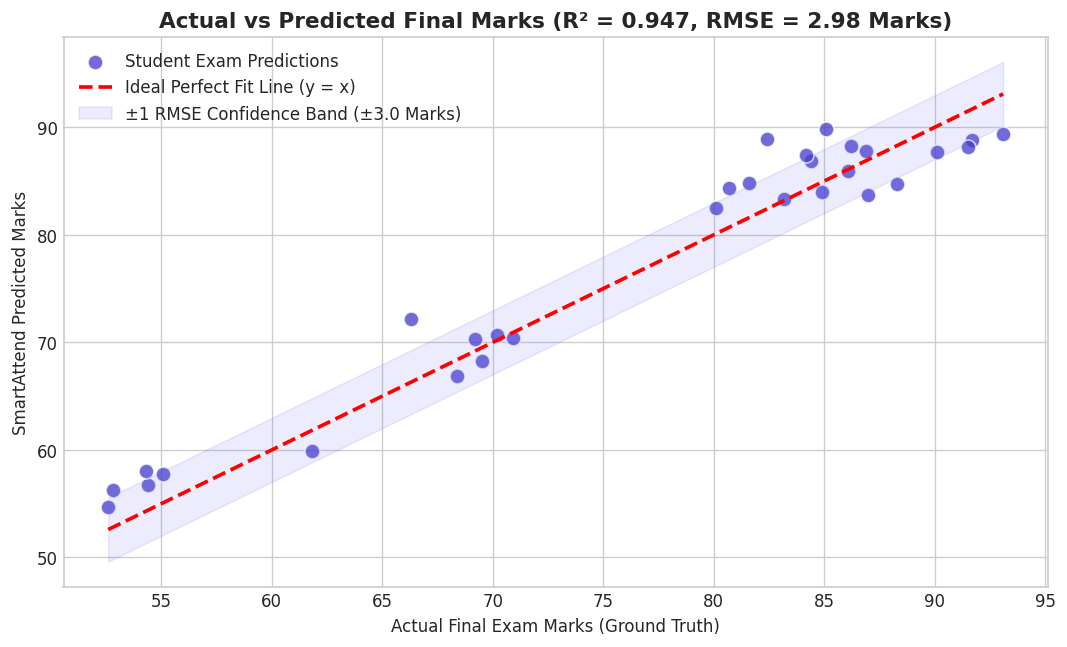

In [8]:
plt.figure(figsize=(9, 5.5))
plt.scatter(y_test_p, y_pred_p, color='#4338CA', alpha=0.75, edgecolors='w', s=80, label='Student Exam Predictions')
min_val, max_val = min(y_test_p.min(), y_pred_p.min()), max(y_test_p.max(), y_pred_p.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2.2, label='Ideal Perfect Fit Line (y = x)')
plt.fill_between([min_val, max_val], [min_val - rmse, max_val - rmse], [min_val + rmse, max_val + rmse],
                 color='#6366F1', alpha=0.12, label=f'±1 RMSE Confidence Band (±{rmse:.1f} Marks)')

plt.title(f'Actual vs Predicted Final Marks (R² = {r2:.3f}, RMSE = {rmse:.2f} Marks)', fontsize=13, fontweight='bold')
plt.xlabel('Actual Final Exam Marks (Ground Truth)')
plt.ylabel('SmartAttend Predicted Marks')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


## 👥 Section 5: Model 3 — Student Behavioral Segmentation (`K-Means Clustering`)
**Pedagogical Purpose:** Faculty need to categorize students into distinct educational personas to provide tailored, differentiated instruction:
- **Cluster 0:** 🌟 *Star Performers* (High Attendance + High Quizzes + Strong Self-Study)
- **Cluster 1:** ⚠️ *At-Risk Inconsistent* (Low Attendance + High Absence Streak)
- **Cluster 2:** 📈 *Dedicated Improvers* (Average Attendance + High Learning Portal Hours)
- **Cluster 3:** 💤 *Disengaged Students* (Low Attendance + Low Course Completion)


  File "C:\Users\rajan\AppData\Local\Programs\Python\Python312\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\rajan\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\rajan\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\rajan\AppData\Local\Programs\Python\Python312\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,
                       ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


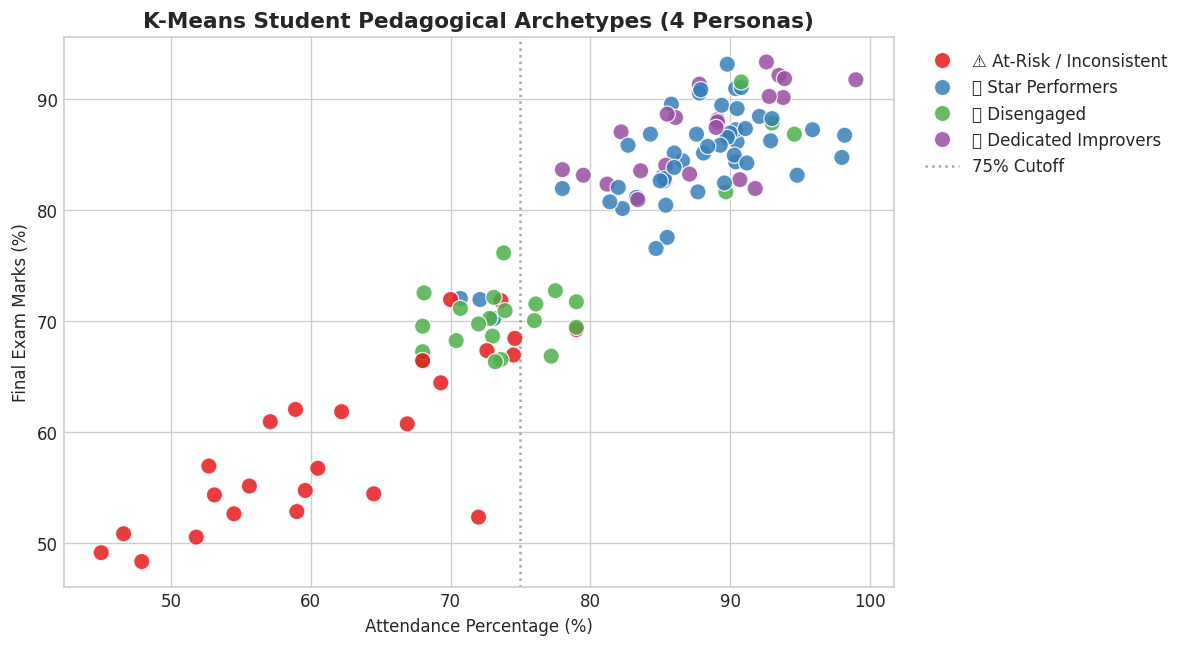

In [9]:
cluster_features = ["attendance_percentage", "quiz_average", "course_completion", "learning_minutes"]
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df[cluster_features])

persona_names = {
    0: "🌟 Star Performers",
    1: "⚠️ At-Risk / Inconsistent",
    2: "📈 Dedicated Improvers",
    3: "💤 Disengaged"
}
df['persona'] = df['cluster'].map(persona_names)

plt.figure(figsize=(10, 5.5))
sns.scatterplot(
    x='attendance_percentage', y='final_exam_score',
    hue='persona', data=df, s=95, palette='Set1', alpha=0.85
)
plt.title('K-Means Student Pedagogical Archetypes (4 Personas)', fontsize=13, fontweight='bold')
plt.xlabel('Attendance Percentage (%)')
plt.ylabel('Final Exam Marks (%)')
plt.axvline(75, color='gray', linestyle=':', alpha=0.7, label='75% Cutoff')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


## 🚨 Section 6: Model 4 — Attendance Anomaly Detection (`IsolationForest`)
**Security Standard:** Detects anomalous attendance events (e.g. proxy attendance, sudden attendance collapse, or irregular presence bursts).


In [10]:
iso_features = ["attendance_percentage", "absence_streak", "late_count", "attendance_trend"]
iso_forest = IsolationForest(contamination=0.08, random_state=42)
df['anomaly_flag'] = iso_forest.fit_predict(df[iso_features])
# 1 = Normal, -1 = Anomaly

anomalies = df[df['anomaly_flag'] == -1]
print(f"🚨 Isolation Forest detected {len(anomalies)} anomalous patterns out of {len(df)} students.")
display(anomalies[['roll_number', 'student_name', 'attendance_percentage', 'absence_streak', 'late_count', 'risk_label']].head(5))


🚨 Isolation Forest detected 10 anomalous patterns out of 120 students.


,roll_number,student_name,attendance_percentage,absence_streak,late_count,risk_label
0,S101,Rahul Sharma,55.6,7,5,HIGH
7,S108,Kavita Iyer,59.6,6,2,HIGH
9,S110,Nikhil Kumar,52.7,2,2,HIGH
10,S111,Harsh Nair,99.0,1,2,LOW
24,S125,Gaurav Patel,45.0,5,3,HIGH


## 💡 Section 7: Live Interactive Student Prediction Sandbox (Teacher Demonstration)
Teachers can test any student roll number or input custom values to see the **instant multi-model evaluation card** with explainable root causes and targeted interventions.


In [11]:
def evaluate_student(student_input):
    """
    Unified inference function that takes a student dict or roll number
    and runs all models: Risk, Expected Marks, Cluster Persona, and Anomalies.
    """
    if isinstance(student_input, str):
        match = df[(df['roll_number'].str.upper() == student_input.upper()) | 
                   (df['student_name'].str.lower() == student_input.lower())]
        if match.empty:
            print(f"❌ Student '{student_input}' not found in dataset!")
            return
        row = match.iloc[0]
    else:
        row = pd.Series(student_input)

    # 1. Risk Prediction
    r_input = pd.DataFrame([row[risk_features]])
    risk_pred = risk_model.predict(r_input)[0]
    risk_proba = risk_model.predict_proba(r_input)[0]
    risk_conf = max(risk_proba) * 100

    # 2. Performance Prediction
    p_input = pd.DataFrame([row[perf_features]])
    marks_pred = perf_model.predict(p_input)[0]
    lower_band = max(0, marks_pred - rmse)
    upper_band = min(100, marks_pred + rmse)

    # 3. Persona / Cluster
    c_input = pd.DataFrame([row[cluster_features]])
    cluster_id = kmeans.predict(c_input)[0]
    persona = persona_names.get(cluster_id, "Standard Student")

    # 4. Anomaly
    a_input = pd.DataFrame([row[iso_features]])
    is_anom = iso_forest.predict(a_input)[0] == -1

    # Visual Formatted Report
    risk_icon = "🟢" if risk_pred == "LOW" else ("🟡" if risk_pred == "MEDIUM" else "🔴")
    print("=" * 68)
    print(f"🎓 SMARTATTEND AI — ACADEMIC EVALUATION CARD")
    print("=" * 68)
    print(f"👤 Student Name    : {row.get('student_name', 'Custom Test Candidate')}")
    print(f"🆔 Roll Number     : {row.get('roll_number', 'TEST-001')} • Sem {row.get('semester', 6)} CSE")
    print(f"📅 Attendance Rate : {row['attendance_percentage']:.1f}% ({int(row['classes_attended'])} Attended, {int(row['classes_missed'])} Missed)")
    print(f"🔥 Absence Streak  : {int(row['absence_streak'])} consecutive lectures missed")
    print(f"📝 Quiz Average    : {row['quiz_average']:.1f}% | Assignment Average: {row['assignment_average']:.1f}%")
    print("-" * 68)
    print(f"🎯 ATTENDANCE RISK : {risk_icon} {risk_pred} RISK  (Model Confidence: {risk_conf:.1f}%)")
    print(f"📈 PREDICTED MARKS : {marks_pred:.1f}%  [95% Confidence Band: {lower_band:.1f}% — {upper_band:.1f}%]")
    print(f"👥 LEARNER PERSONA : {persona}")
    print(f"🚨 ANOMALY STATUS  : {'⚠️ ANOMALOUS BEHAVIOR DETECTED' if is_anom else '✅ Normal Attendance Pattern'}")
    print("-" * 68)
    print("🔍 KEY ATTRIBUTION FACTORS (EXPLAINABLE AI):")
    if row['attendance_percentage'] < 75:
        print(f"   • ⚠️ Attendance ({row['attendance_percentage']:.1f}%) is BELOW 75% university eligibility cutoff.")
    else:
        print(f"   • ✅ Attendance ({row['attendance_percentage']:.1f}%) satisfies university 75% norm.")
    if row['absence_streak'] >= 3:
        print(f"   • ⚠️ Critical absence streak: {int(row['absence_streak'])} classes missed consecutively.")
    if row['quiz_average'] < 60:
        print(f"   • ⚠️ Formative quiz average ({row['quiz_average']:.1f}%) indicates conceptual knowledge gaps.")

    print("\n💡 ACTIONABLE FACULTY INTERVENTIONS:")
    if risk_pred == 'HIGH':
        print("   1. [Urgent Alert] Send automated notification regarding mandatory 75% criteria.")
        print("   2. [Mentorship] Mandate counseling session with Department Academic Proctor.")
        print("   3. [Remedial Action] Assign formative practice quizzes on low-scoring topics.")
    elif risk_pred == 'MEDIUM':
        print("   1. [Proactive Warning] Alert student to prevent absence streak from crossing 3 classes.")
        print("   2. [Support] Provide high-yield revision summaries and assignment extensions.")
    else:
        print("   1. [Enrichment] Nominate for advanced seminar projects and peer tutoring.")
        print("   2. [Recognition] Issue high academic streak badge.")
    print("=" * 68)


In [12]:
# Demo 1: High Risk Case — Rahul Sharma (S101)
evaluate_student("S101")


🎓 SMARTATTEND AI — ACADEMIC EVALUATION CARD
👤 Student Name    : Rahul Sharma
🆔 Roll Number     : S101 • Sem 6 CSE
📅 Attendance Rate : 55.6% (25 Attended, 20 Missed)
🔥 Absence Streak  : 7 consecutive lectures missed
📝 Quiz Average    : 50.4% | Assignment Average: 60.6%
--------------------------------------------------------------------
🎯 ATTENDANCE RISK : 🔴 HIGH RISK  (Model Confidence: 100.0%)
📈 PREDICTED MARKS : 57.8%  [95% Confidence Band: 54.8% — 60.8%]
👥 LEARNER PERSONA : ⚠️ At-Risk / Inconsistent
🚨 ANOMALY STATUS  : ⚠️ ANOMALOUS BEHAVIOR DETECTED
--------------------------------------------------------------------
🔍 KEY ATTRIBUTION FACTORS (EXPLAINABLE AI):
   • ⚠️ Attendance (55.6%) is BELOW 75% university eligibility cutoff.
   • ⚠️ Critical absence streak: 7 classes missed consecutively.
   • ⚠️ Formative quiz average (50.4%) indicates conceptual knowledge gaps.

💡 ACTIONABLE FACULTY INTERVENTIONS:
   1. [Urgent Alert] Send automated notification regarding mandatory 75% criter

In [13]:
# Demo 2: Low Risk Star Performer — Aditi Patil (S102)
evaluate_student("S102")


🎓 SMARTATTEND AI — ACADEMIC EVALUATION CARD
👤 Student Name    : Aditi Patil
🆔 Roll Number     : S102 • Sem 6 CSE
📅 Attendance Rate : 70.7% (32 Attended, 13 Missed)
🔥 Absence Streak  : 1 consecutive lectures missed
📝 Quiz Average    : 62.2% | Assignment Average: 78.6%
--------------------------------------------------------------------
🎯 ATTENDANCE RISK : 🟡 MEDIUM RISK  (Model Confidence: 94.2%)
📈 PREDICTED MARKS : 71.3%  [95% Confidence Band: 68.3% — 74.2%]
👥 LEARNER PERSONA : 🌟 Star Performers
🚨 ANOMALY STATUS  : ✅ Normal Attendance Pattern
--------------------------------------------------------------------
🔍 KEY ATTRIBUTION FACTORS (EXPLAINABLE AI):
   • ⚠️ Attendance (70.7%) is BELOW 75% university eligibility cutoff.

💡 ACTIONABLE FACULTY INTERVENTIONS:
   1. [Proactive Warning] Alert student to prevent absence streak from crossing 3 classes.
   2. [Support] Provide high-yield revision summaries and assignment extensions.


In [14]:
# Demo 3: Live Custom Student Input (Simulating a Teacher Testing Any Value)
custom_student = {
    "student_name": "New Test Candidate",
    "roll_number": "S999",
    "semester": 6,
    "attendance_percentage": 58.0,
    "absence_streak": 4,
    "late_count": 3,
    "attendance_trend": -0.35,
    "classes_attended": 26,
    "classes_missed": 19,
    "quiz_average": 52.0,
    "assignment_average": 60.0,
    "learning_minutes": 180.0,
    "course_completion": 45.0,
    "previous_exam_score": 55.0,
    "recent_score_trend": -0.2
}
evaluate_student(custom_student)


🎓 SMARTATTEND AI — ACADEMIC EVALUATION CARD
👤 Student Name    : New Test Candidate
🆔 Roll Number     : S999 • Sem 6 CSE
📅 Attendance Rate : 58.0% (26 Attended, 19 Missed)
🔥 Absence Streak  : 4 consecutive lectures missed
📝 Quiz Average    : 52.0% | Assignment Average: 60.0%
--------------------------------------------------------------------
🎯 ATTENDANCE RISK : 🔴 HIGH RISK  (Model Confidence: 100.0%)
📈 PREDICTED MARKS : 58.4%  [95% Confidence Band: 55.4% — 61.3%]
👥 LEARNER PERSONA : ⚠️ At-Risk / Inconsistent
🚨 ANOMALY STATUS  : ⚠️ ANOMALOUS BEHAVIOR DETECTED
--------------------------------------------------------------------
🔍 KEY ATTRIBUTION FACTORS (EXPLAINABLE AI):
   • ⚠️ Attendance (58.0%) is BELOW 75% university eligibility cutoff.
   • ⚠️ Critical absence streak: 4 classes missed consecutively.
   • ⚠️ Formative quiz average (52.0%) indicates conceptual knowledge gaps.

💡 ACTIONABLE FACULTY INTERVENTIONS:
   1. [Urgent Alert] Send automated notification regarding mandatory 75% 